# 🏁 Análise Unificada Multi-Piloto — Delta Time & Evolução por Stint

Este notebook consolida **todos** os pilotos e stints registrados em `datasets.py` (2 pistas: Charlotte Roval 2025 e Summit Point) para gerar:

1. Delta time — **Experiente vs Intermediário**
2. Delta time — **Amadores vs Intermediário** (subplots)
3. Evolução do tempo de volta ao longo dos stints
4. Tabela-resumo pronta para atualizar a **Tabela 5** do artigo

> ⚠️ **Nota sobre papéis dos pilotos**: há divergência entre `driver_alias.py` (Rodrigo=A, Tomaz=B, Morsinaldo=C) e classificações anteriores do artigo. Este notebook usa a classificação mais recente informada por Tomaz:
> - **Rodrigo** → Experiente
> - **Tomaz** → Intermediário (referência das comparações com amadores)
> - **Morsinaldo** → Amador original
> - **Thallys, Igor, Hilton** → Amadores novos
>
> Revise `ROLE_MAP` abaixo antes de gerar as figuras finais para o artigo.


## 1. Setup e imports

In [1]:
import sys
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import (
    DATASETS, DRIVER_ALIAS, resolve_stint_files, load_stint,
    basic_clean_and_units, build_lap_validity_table, TRACK_CONFIGS,
)

print(f"Pistas no dataset : {list(DATASETS.keys())}")
for track_id, cfg in DATASETS.items():
    drivers = list(cfg["sessions"].keys())
    print(f"  {track_id}: pilotos = {drivers}")


Pistas no dataset : ['charlotte_roval_2025', 'summit_point']
  charlotte_roval_2025: pilotos = ['Tomaz', 'Morsinaldo', 'Rodrigo', 'Thallys', 'Igor', 'Hilton']
  summit_point: pilotos = ['Tomaz', 'Morsinaldo', 'Rodrigo', 'Thallys', 'Igor', 'Hilton']


In [2]:
# --- Papéis dos pilotos (Roles) em Inglês ---
ROLE_MAP = {
    "Rodrigo":    "Expert",
    "Tomaz":      "Intermediate",
    "Morsinaldo": "Beginner (original)",
    "Thallys":    "Beginner (new)",
    "Igor":       "Beginner (new)",
    "Hilton":     "Beginner (new)",
}

REFERENCE_INTERMEDIATE = "Tomaz"
REFERENCE_EXPERT       = "Rodrigo"
AMATEURS               = ["Morsinaldo", "Thallys", "Igor", "Hilton"]

ROLE_COLORS = {
    "Expert":              "#1f77b4",
    "Intermediate":        "#2ca02c",
    "Beginner (original)": "#ff7f0e",
    "Beginner (new)":      "#d62728",
}

OUT_DIR = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all" / "Iracing" / "img" / "unified_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis


## 2. Carregamento de todos os lap times (todas as pistas, pilotos e stints)

Percorre `DATASETS` dinamicamente — se você adicionar um piloto ou stint novo no `datasets.py`, este bloco já processa automaticamente.

Esta tabela (`master_laps`) é a **fonte única de verdade** sobre qual (piloto, pista, stint, volta) é a mais rápida — as seções seguintes reutilizam esses números em vez de recalcular concatenando telemetria de múltiplos stints (o que arriscaria colidir números de volta entre stints diferentes).

In [3]:
def build_master_laptime_table(datasets=DATASETS, role_map=ROLE_MAP, verbose=True):
    """Varre todas as pistas/pilotos/stints e monta uma tabela única de lap times."""
    rows = []
    for track_id, cfg in datasets.items():
        sessions = cfg["sessions"]
        for driver, stints in sessions.items():
            for stint_name in stints.keys():
                try:
                    files = [str(p) for p in resolve_stint_files(track_id, driver, stint_name)]
                    raw = load_stint(files)
                    df = basic_clean_and_units(raw)
                    lap_df = build_lap_validity_table(df)

                    lap_df = lap_df.copy()
                    lap_df["Track"]  = track_id
                    lap_df["Driver"] = driver
                    lap_df["Role"]   = role_map.get(driver, "Desconhecido")
                    lap_df["Stint"]  = stint_name

                    rows.append(lap_df)
                    if verbose:
                        n_valid = int(lap_df["Valid"].sum())
                        print(f"OK {track_id:22s} | {driver:11s} | {stint_name:10s} | {n_valid} voltas validas")
                except Exception as e:
                    print(f"FALHA em {track_id}/{driver}/{stint_name}: {e}")

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


In [4]:
# --- Execução (usa cache em pickle para reprocessamentos futuros) ---
CACHE_PATH = OUT_DIR / "master_laps_cache.pkl"
FORCE_RELOAD = True  # mude para True para reprocessar tudo do zero

if CACHE_PATH.exists() and not FORCE_RELOAD:
    master_laps = pd.read_pickle(CACHE_PATH)
    print(f"Cache carregado: {len(master_laps)} linhas")
else:
    master_laps = build_master_laptime_table()
    master_laps.to_pickle(CACHE_PATH)
    print(f"Processado do zero e salvo em cache: {len(master_laps)} linhas")

master_laps.head()


    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
OK charlotte_roval_2025   | Tomaz       | stint_1    | 25 voltas validas
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt … OK (148,787 samples, laps 17–40)
──────────────────────────────────────────────────────────────

,Lap,LapTime_s,StartPct,CompletedPct,FracLowSpeed,MaxSpeed_kph,GpsCoverage_Pct,Valid,InvalidReason,Track,Driver,Role,Stint
0,0,2917.466667,0.000000,0.999983,0.298218,187.265794,0.95,False,FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0...,charlotte_roval_2025,Tomaz,Intermediate,stint_1
1,1,98.266667,0.000138,0.999994,0.000000,185.910892,1.00,True,OK,charlotte_roval_2025,Tomaz,Intermediate,stint_1
2,2,99.416667,0.000151,0.999864,0.000000,187.020374,1.00,True,OK,charlotte_roval_2025,Tomaz,Intermediate,stint_1
3,3,98.083333,0.000020,0.999946,0.000000,186.413132,1.00,True,OK,charlotte_roval_2025,Tomaz,Intermediate,stint_1
4,4,97.283333,0.000104,0.999954,0.000000,187.154379,1.00,True,OK,charlotte_roval_2025,Tomaz,Intermediate,stint_1


## 3. Delta Time — Experiente vs Intermediário

In [5]:
def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> dict:
    """Alinha uma volta por LapDistPct em um grid comum."""
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y):
        return np.interp(grid, x, y)

    return {
        "LapDistPct": grid,
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
    }


def get_best_stint_and_lap(track_id: str, driver: str, master_laps: pd.DataFrame, target_stint: str = None):
    """Consulta master_laps pela melhor volta válida. Opcionalmente filtra por um stint específico."""
    valid = master_laps[
        (master_laps["Track"] == track_id)
        & (master_laps["Driver"] == driver)
        & (master_laps["Valid"])
    ]
    
    # Se um stint específico for solicitado (ex: 'stint_1'), aplicamos o filtro
    if target_stint:
        valid = valid[valid["Stint"] == target_stint]

    if valid.empty:
        raise RuntimeError(f"No valid lap for {driver} at {track_id} (Stint: {target_stint})")
        
    best_row = valid.sort_values("LapTime_s").iloc[0]
    return str(best_row["Stint"]), int(best_row["Lap"]), float(best_row["LapTime_s"])


def load_stint_telemetry(track_id: str, driver: str, stint_name: str) -> pd.DataFrame:
    files = [str(p) for p in resolve_stint_files(track_id, driver, stint_name)]
    raw = load_stint(files)
    return basic_clean_and_units(raw)


def plot_delta_time(track_id: str, driver_ref: str, driver_test: str, master_laps: pd.DataFrame,
                     ax=None, grid_len: int = 2000, title_suffix: str = "", 
                     target_stint_ref: str = None, target_stint_test: str = None):
    """
    Plota o delta de tempo (test - ref), usando a MELHOR volta válida de cada piloto.
    Permite definir stints diferentes para o piloto de referência e o piloto em teste.
    """
    
    # Buscamos a volta de referência fixada no stint desejado (ex: stint_1)
    stint_ref, lap_ref, t_ref = get_best_stint_and_lap(track_id, driver_ref, master_laps, target_stint_ref)
    # Buscamos a volta do piloto em teste no seu stint atual de análise (ex: stint_5)
    stint_test, lap_test, t_test = get_best_stint_and_lap(track_id, driver_test, master_laps, target_stint_test)

    df_ref = load_stint_telemetry(track_id, driver_ref, stint_ref)
    df_test = load_stint_telemetry(track_id, driver_test, stint_test)

    grid = np.linspace(0.0, 1.0, grid_len)
    g_ref = df_ref[df_ref["Lap"] == lap_ref]
    g_test = df_test[df_test["Lap"] == lap_test]

    interp_ref = align_lap_by_dist(g_ref, grid)
    interp_test = align_lap_by_dist(g_test, grid)

    time_loss = interp_test["t_rel"] - interp_ref["t_rel"]
    final_delta = time_loss[-1]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(grid * 100.0, time_loss, color="firebrick", linewidth=2.2, label="Time Delta")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)

    alias_ref = DRIVER_ALIAS.get(driver_ref, f"Driver {driver_ref}")
    alias_test = DRIVER_ALIAS.get(driver_test, f"Driver {driver_test}")

    # Atualizando o texto informativo para mostrar claramente os stints comparados
    info_text = (
        f"REF ({alias_ref}, Stint {stint_ref.split('_')[-1]}): {t_ref:.3f}s\n"
        f"TEST ({alias_test}, Stint {stint_test.split('_')[-1]}): {t_test:.3f}s\n"
        f"DIFF: {final_delta:+.3f}s"
    )
    
    ax.text(0.02, 0.97, info_text, transform=ax.transAxes, fontsize=8,
            va="top", family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="gray"))

    ax.set_xlabel("Lap progress (%)")
    ax.set_ylabel("Time delta (s)")
    
    ax.set_title(f"{alias_test} vs {alias_ref}{title_suffix}", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right")

    if standalone:
        plt.tight_layout()
        fname = f"delta_{track_id}_{alias_test}_vs_{alias_ref}.pdf"
        plt.savefig(OUT_DIR / fname, format='pdf', dpi=300, bbox_inches="tight")
        print(f"Saved: {OUT_DIR / fname}")
        plt.show()

    return final_delta


=== Charlotte Roval 2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-05-11 23-11-08.ibt … OK (55,207 samples, laps 0–9)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_charlotte_roval_2025_Driver B_vs_Driver A.pdf


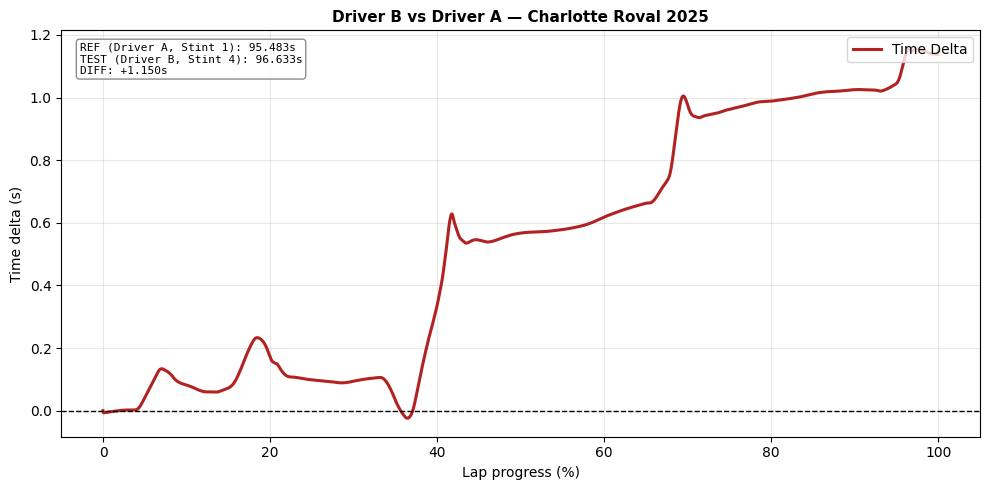


=== Summit Point - Main Circuit ===
    [1/2] Loading toyotagr86_summit summit raceway 2026-03-01 22-00-14(Rodrigo).ibt … OK (46,538 samples, laps 0–32)
    [2/2] Loading toyotagr86_summit summit raceway 2026-03-01 21-47-29(Rodrigo).ibt … OK (44,508 samples, laps 33–52)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_summit_point_Driver B_vs_Driver A.pdf


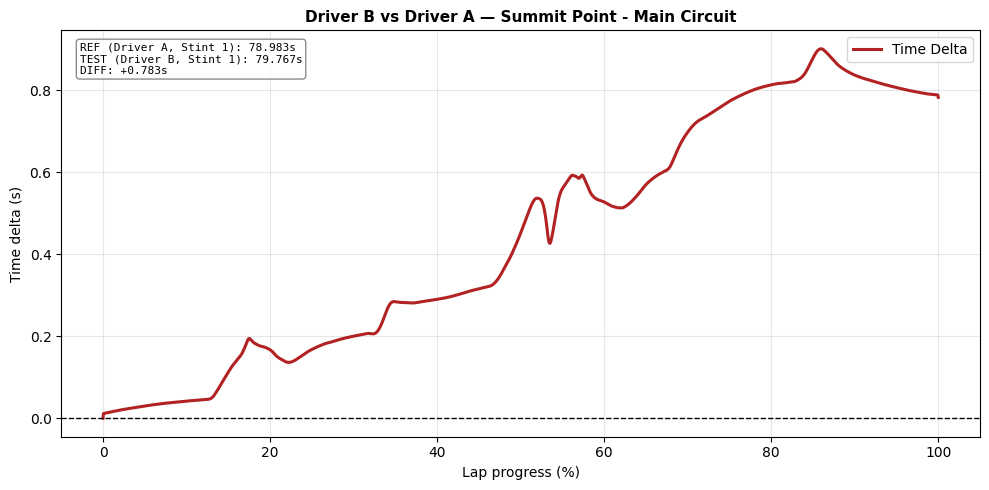

In [6]:
# --- Execução: Experiente vs Intermediário, para cada pista disponível ---
for track_id in DATASETS.keys():
    track_name = TRACK_CONFIGS[track_id]["track_name"]
    print(f"\n=== {track_name} ===")
    plot_delta_time(track_id, driver_ref=REFERENCE_EXPERT, driver_test=REFERENCE_INTERMEDIATE,
                     master_laps=master_laps, title_suffix=f" — {track_name}")


## 4. Delta Time — Amadores vs Intermediário (subplots)

In [7]:
def plot_amateur_grid(track_id: str, master_laps: pd.DataFrame, amateurs=AMATEURS, 
                      reference=REFERENCE_INTERMEDIATE, 
                      target_stint_ref="stint_1", target_stint_test="stint_1"):
    """
    Gera matriz de gráficos unificando o eixo Y e focando na comparação 
    entre o stint de referência e o stint de teste.
    """
    n = len(amateurs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    deltas = {}
    valid_axes = [] 
    
    for i, driver in enumerate(amateurs):
        ax = axes_flat[i]
        alias_driver = DRIVER_ALIAS.get(driver, f"Driver {driver}")
        
        try:
            # Chama a função passando os stints separados
            final_delta = plot_delta_time(track_id, driver_ref=reference, driver_test=driver,
                                           master_laps=master_laps, ax=ax, 
                                           target_stint_ref=target_stint_ref,
                                           target_stint_test=target_stint_test)
            deltas[driver] = final_delta
            valid_axes.append(ax) 
        except Exception as e:
            ax.set_title(f"{alias_driver}: error ({e})", fontsize=9, color="red")

    # Escala de Y uniforme em todos os subplots para garantir comparação visual justa
    if valid_axes:
        y_mins = [ax.get_ylim()[0] for ax in valid_axes]
        y_maxs = [ax.get_ylim()[1] for ax in valid_axes]
        global_y_min, global_y_max = min(y_mins), max(y_maxs)
        
        for ax in valid_axes:
            ax.set_ylim(global_y_min, global_y_max)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    track_name = TRACK_CONFIGS[track_id]["track_name"]
    alias_ref = DRIVER_ALIAS.get(reference, f"Driver {reference}")
    
    # Formatação do Título Principal baseada nos stints passados
    stint_test_label = target_stint_test.replace("_", " ").title() if target_stint_test else "All Stints"
    stint_ref_label = target_stint_ref.replace("_", " ").title() if target_stint_ref else "All Stints"
    
    fig.suptitle(f"Beginners ({stint_test_label}) vs Intermediate ({alias_ref} - {stint_ref_label}) — {track_name}", 
                 fontsize=14, fontweight="bold")
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Nomenclatura dinâmica do arquivo PDF para evitar sobrescrever fases diferentes do estudo
    test_str = target_stint_test if target_stint_test else "all"
    ref_str = target_stint_ref if target_stint_ref else "all"
    fname = f"delta_grid_beginners_{track_id}_T{test_str}_vs_R{ref_str}.pdf"
    
    plt.savefig(OUT_DIR / fname, format='pdf', dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / fname}")
    plt.show()

    return deltas

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-03 18-20-07(Morsinaldo-stint5).ibt … OK (19,004 samples, laps 0–3)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-01 21-38-37(Thallys-stint5).ibt … OK (41,237 samples, laps 0–6)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-11 15-58-02(igor-stint5).ibt … OK (43,577 samples, laps 0–6)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-06 15-21-27(hilton-stint5).ibt … OK (37,560 samples, laps 0–6)
Saved: C:\Users\to_fi\OneDrive\Documents\

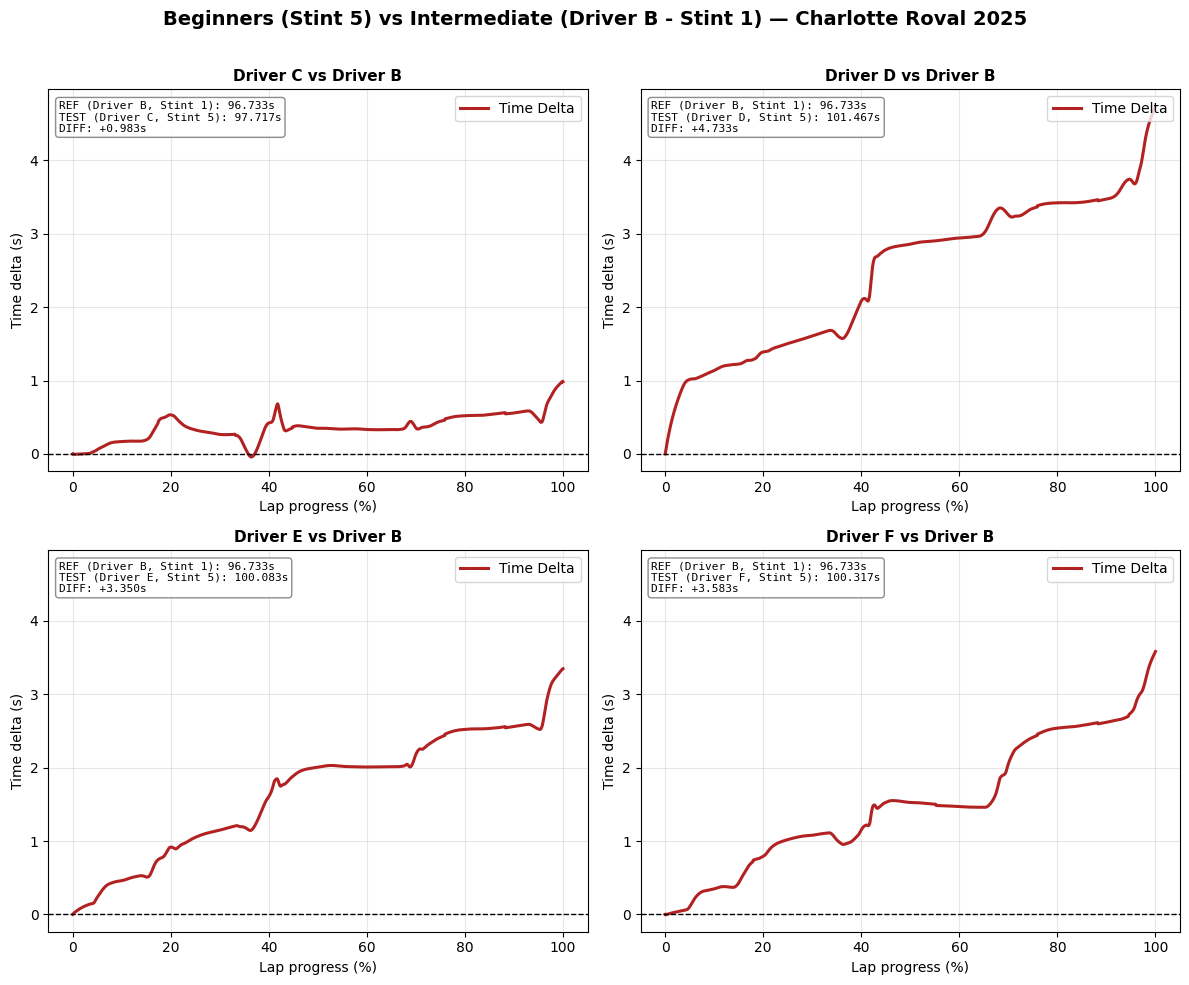

    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-06 17-13-21(morsinaldo-stint5).ibt … OK (69,741 samples, laps 0–14)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-06 22-01-39(Thallys-stint5).ibt … OK (42,675 samples, laps 0–9)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-11 17-38-46(igor-stint5).ibt … OK (16,934 samples, laps 0–4)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-07 14-21-27(hilton-stint5).ibt … OK (16,655 samples, laps 0–4)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing

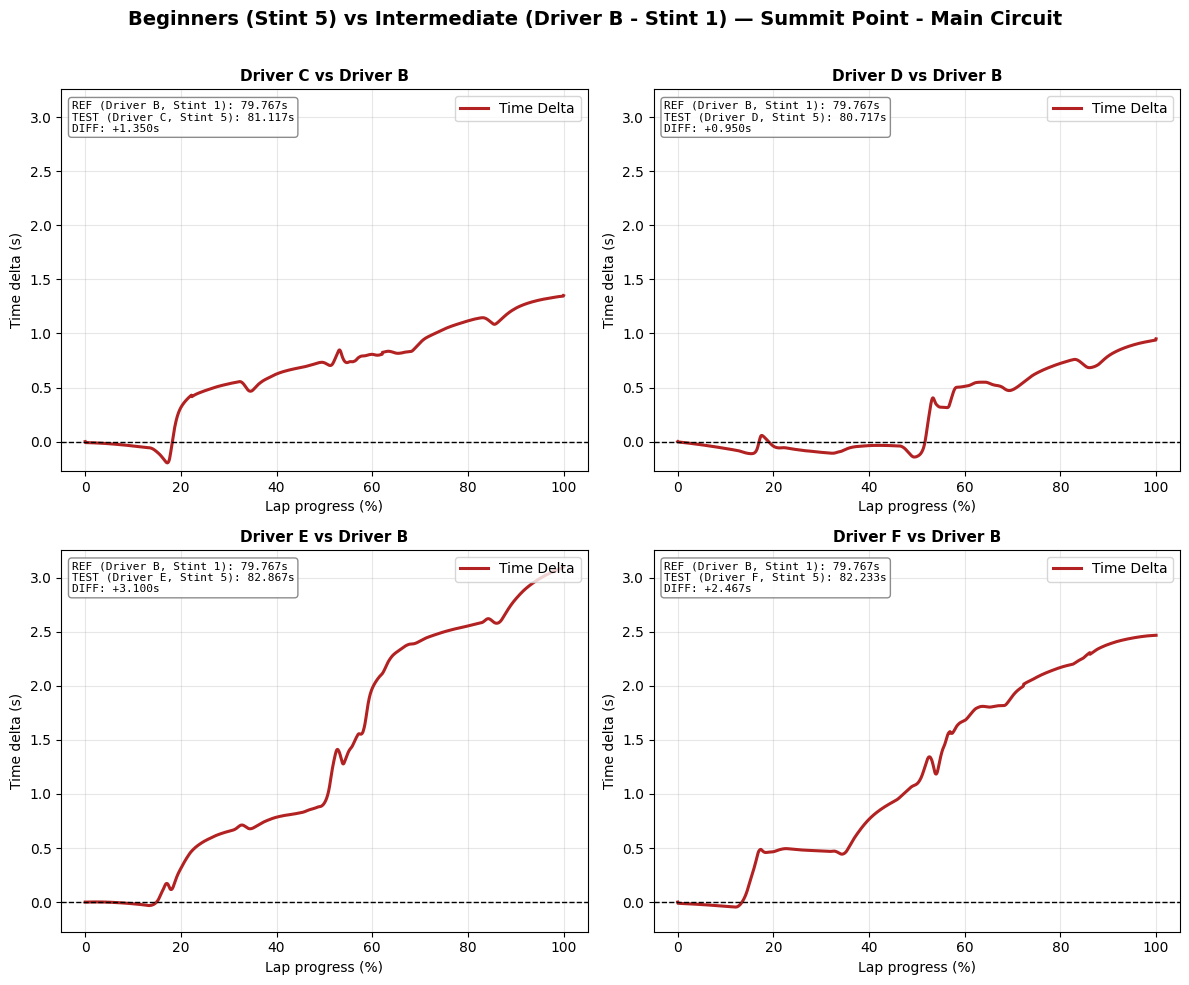

In [8]:
for track_id in DATASETS.keys():
    plot_amateur_grid(track_id, master_laps, amateurs=AMATEURS, 
                      target_stint_ref="stint_1", target_stint_test="stint_5")

## 5. Evolução do tempo de volta ao longo dos stints

Objetivo: verificar efeito de prática/familiarização — relevante para os revisores que questionam se a melhora pós-coaching não é simplesmente aprendizado por repetição (Revisor 1 e 2, item de grupo de controle).

In [12]:
import re

def stint_sort_key(stint_name: str):
    """Extrai o número do stint para ordenação (ex.: 'stint_3' -> 3). Não numéricos vão pro início (warmup)."""
    m = re.search(r"(\d+)", stint_name)
    return int(m.group(1)) if m else -1


def build_stint_progression_table(master_laps: pd.DataFrame, exclude_warmup=True):
    df = master_laps[master_laps["Valid"]].copy()
    if exclude_warmup:
        df = df[~df["Stint"].str.contains("warmup|aquecimento", case=False, na=False)]

    df["StintOrder"] = df["Stint"].apply(stint_sort_key)

    agg = (
        df.groupby(["Track", "Driver", "Role", "Stint", "StintOrder"])["LapTime_s"]
        .agg(best="min", mean="mean", n="count")
        .reset_index()
        .sort_values(["Track", "Driver", "StintOrder"])
    )
    return agg


def plot_stint_progression(progression_df: pd.DataFrame, track_id: str, metric="best"):
    df_track = progression_df[progression_df["Track"] == track_id]

    fig, ax = plt.subplots(figsize=(11, 6))
    for driver, g in df_track.groupby("Driver"):
        role = ROLE_MAP.get(driver, "Desconhecido")
        color = ROLE_COLORS.get(role, "gray")
        is_new = "novo" in role
        ax.plot(g["StintOrder"], g[metric], marker="o", label=f"{driver} ({role})",
                color=color, linewidth=2, alpha=0.7 if is_new else 1.0,
                linestyle="--" if is_new else "-")

    track_name = TRACK_CONFIGS[track_id]["track_name"]
    ax.set_xlabel("Stint")
    ax.set_ylabel(f"Lap time {metric} (s)")
    ax.set_title(f"Laptime per Stint — {track_name}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"stint_progression_{track_id}_{metric}.pdf"
    plt.savefig(OUT_DIR / fname, dpi=300, bbox_inches="tight")
    print(f"Salvo: {OUT_DIR / fname}")
    plt.show()


Salvo: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\stint_progression_charlotte_roval_2025_best.pdf


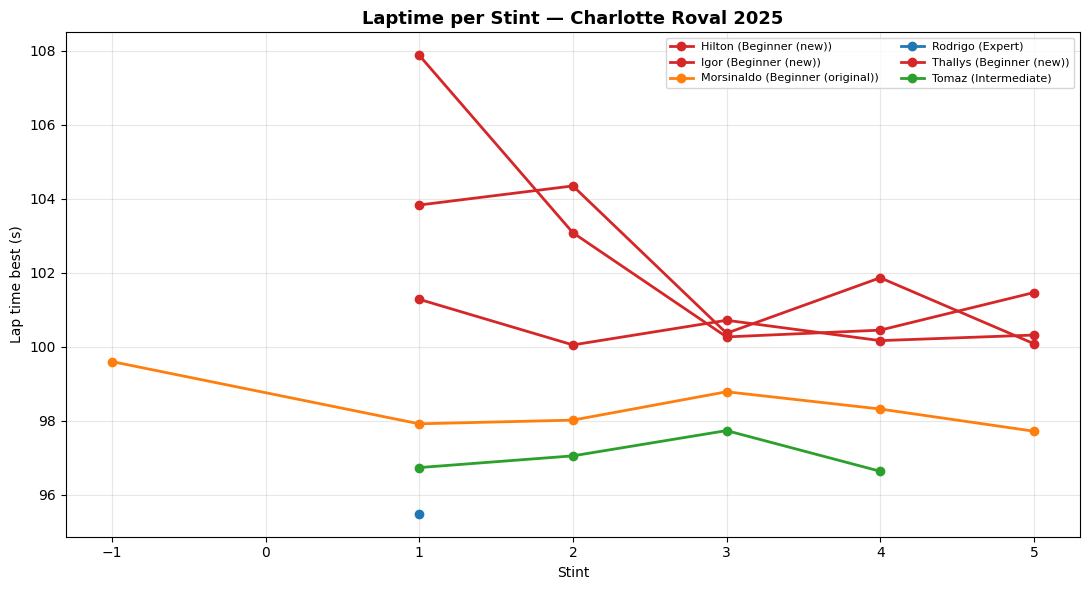

Salvo: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\stint_progression_summit_point_best.pdf


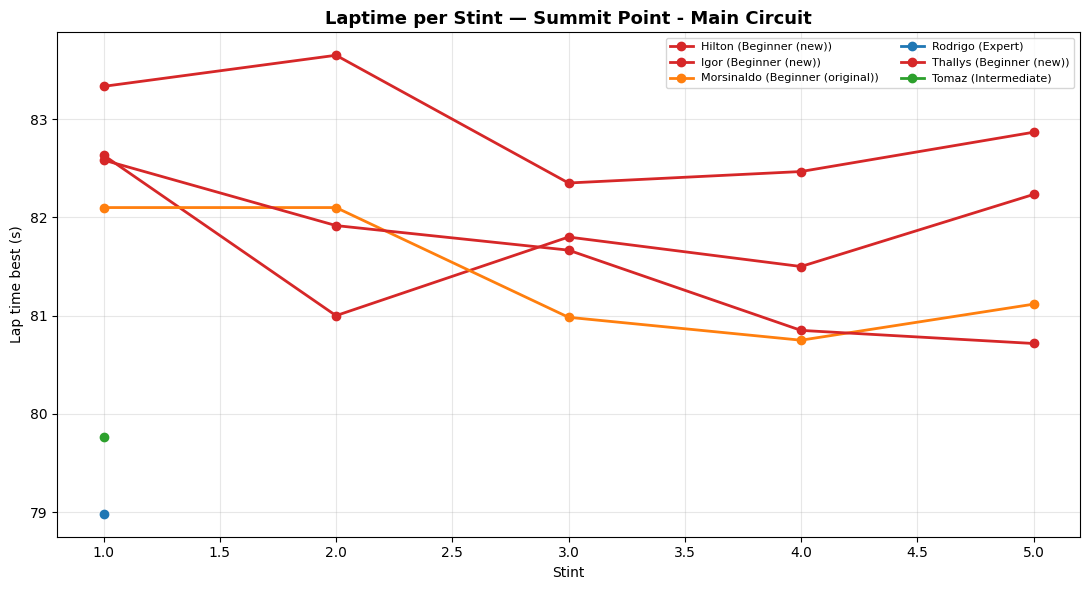

,Track,Driver,Role,Stint,StintOrder,best,mean,n
0,charlotte_roval_2025,Hilton,Beginner (new),stint_1,1,101.283333,105.104167,4
1,charlotte_roval_2025,Hilton,Beginner (new),stint_2,2,100.050000,101.337500,4
2,charlotte_roval_2025,Hilton,Beginner (new),stint_3,3,100.716667,101.425000,2
3,charlotte_roval_2025,Hilton,Beginner (new),stint_4,4,100.166667,102.997222,6
4,charlotte_roval_2025,Hilton,Beginner (new),stint_5,5,100.316667,101.416667,4
5,charlotte_roval_2025,Igor,Beginner (new),stint_1,1,103.833333,111.258333,6
6,charlotte_roval_2025,Igor,Beginner (new),stint_2,2,104.350000,111.207143,7
7,charlotte_roval_2025,Igor,Beginner (new),stint_3,3,100.366667,101.216667,2
8,charlotte_roval_2025,Igor,Beginner (new),stint_4,4,101.866667,104.113333,5
9,charlotte_roval_2025,Igor,Beginner (new),stint_5,5,100.083333,103.887500,4


In [14]:
progression_df = build_stint_progression_table(master_laps)
for track_id in DATASETS.keys():
    plot_stint_progression(progression_df, track_id, metric="best")

progression_df.head(15)


## 6. Tabela-resumo para atualizar a Tabela 5 do artigo

Colunas: pista, piloto, papel, melhor volta, volta média (válidas), nº de voltas válidas, delta vs Intermediário, delta vs Experiente.

In [15]:
def build_table5_summary(master_laps: pd.DataFrame):
    rows = []
    for track_id in DATASETS.keys():
        valid = master_laps[(master_laps["Track"] == track_id) & (master_laps["Valid"])]
        if valid.empty:
            continue

        ref_best = valid[valid["Driver"] == REFERENCE_INTERMEDIATE]["LapTime_s"].min()
        exp_best = valid[valid["Driver"] == REFERENCE_EXPERT]["LapTime_s"].min()

        for driver, g in valid.groupby("Driver"):
            best = g["LapTime_s"].min()
            rows.append({
                "Track": track_id,
                "Driver": driver,
                "Role": ROLE_MAP.get(driver, "Desconhecido"),
                "BestLap_s": best,
                "MeanLap_s": g["LapTime_s"].mean(),
                "N_ValidLaps": int(len(g)),
                "Best_Stint": g.loc[g["LapTime_s"].idxmin(), "Stint"],
                "Delta_vs_Intermediate_s": best - ref_best if driver != REFERENCE_INTERMEDIATE else 0.0,
                "Delta_vs_Expert_s": best - exp_best if driver != REFERENCE_EXPERT else 0.0,
            })

    return pd.DataFrame(rows).sort_values(["Track", "BestLap_s"])


table5_df = build_table5_summary(master_laps)
table5_df


,Track,Driver,Role,BestLap_s,MeanLap_s,N_ValidLaps,Best_Stint,Delta_vs_Intermediate_s,Delta_vs_Expert_s
3,charlotte_roval_2025,Rodrigo,Expert,95.483333,97.566667,36,stint_1,-1.150000,0.000000
5,charlotte_roval_2025,Tomaz,Intermediate,96.633333,99.290278,72,stint_4,0.000000,1.150000
2,charlotte_roval_2025,Morsinaldo,Beginner (original),97.716667,102.022222,18,stint_5,1.083333,2.233333
0,charlotte_roval_2025,Hilton,Beginner (new),100.050000,103.190667,25,stint_2,3.416667,4.566667
1,charlotte_roval_2025,Igor,Beginner (new),100.083333,107.700000,25,stint_5,3.450000,4.600000
4,charlotte_roval_2025,Thallys,Beginner (new),100.266667,106.946154,26,stint_3,3.633333,4.783333
9,summit_point,Rodrigo,Expert,78.983333,79.476923,13,stint_1,-0.783333,0.000000
11,summit_point,Tomaz,Intermediate,79.766667,80.255556,9,stint_1,0.000000,0.783333
10,summit_point,Thallys,Beginner (new),80.716667,84.665054,31,stint_5,0.950000,1.733333
8,summit_point,Morsinaldo,Beginner (original),80.750000,83.267949,26,stint_4,0.983333,1.766667


### Observações para a atualização manual da Tabela 5

- Confira `ROLE_MAP` no topo do notebook antes de usar estes números no artigo.
- `Delta_vs_Intermediate_s`/`Delta_vs_Expert_s` usam a **melhor volta válida geral** por piloto/pista (não um stint específico); ajuste `build_table5_summary` se a Tabela 5 exigir um stint fixo (ex.: apenas pós-coaching).
- `stint_progression_table.csv` já está pronto para um teste de tendência (ex.: regressão linear do tempo de volta vs. número do stint) na resposta ao Revisor 1/2 sobre efeito de prática.